In [1]:
import pandas as pd
from pipeline import create_X_y_df

In [2]:
df_full = pd.read_parquet("../../data/churn-prediction-25-26/train.parquet")

In [3]:
df = df_full.copy()

In [14]:
# Second Train Test set
cut_off_date_train = pd.Timestamp("2018-11-05")
cut_off_date_test = pd.Timestamp("2018-11-15")

df_X, df_y = create_X_y_df(df = df,
                                t0=cut_off_date_train,
                                t1=cut_off_date_test)

In [23]:
df_X["auth"].unique()

array(['Logged In'], dtype=object)

In [52]:
df_a = df_X.groupby(["userId", "page"]).size().reset_index(name="num_visits")

In [53]:
df_a["page"].unique()

array(['About', 'Add Friend', 'Add to Playlist', 'Downgrade', 'Help',
       'Home', 'Logout', 'NextSong', 'Roll Advert', 'Save Settings',
       'Settings', 'Submit Upgrade', 'Thumbs Down', 'Thumbs Up',
       'Upgrade', 'Error', 'Submit Downgrade'], dtype=object)

In [54]:
df_a = df_a.pivot(index = "userId", columns="page", values="num_visits")

In [55]:
df_a

page,About,Add Friend,Add to Playlist,Downgrade,Error,Help,Home,Logout,NextSong,Roll Advert,Save Settings,Settings,Submit Downgrade,Submit Upgrade,Thumbs Down,Thumbs Up,Upgrade
userId,,,,,,,,,,,,,,,,,
1000035,2.0,14.0,18.0,2.0,NaN,3.0,33.0,11.0,745.0,5.0,1.0,5.0,NaN,1.0,9.0,61.0,5.0
1000103,NaN,NaN,1.0,1.0,NaN,NaN,5.0,2.0,52.0,3.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0
1000164,1.0,5.0,10.0,NaN,NaN,2.0,15.0,3.0,368.0,20.0,1.0,3.0,NaN,1.0,2.0,16.0,1.0
1000168,NaN,10.0,10.0,1.0,NaN,2.0,18.0,6.0,351.0,2.0,1.0,2.0,NaN,1.0,1.0,39.0,1.0
1000182,NaN,4.0,11.0,5.0,NaN,2.0,11.0,5.0,289.0,NaN,NaN,NaN,NaN,1.0,5.0,15.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999241,2.0,5.0,4.0,2.0,NaN,1.0,13.0,5.0,250.0,9.0,NaN,NaN,NaN,1.0,2.0,9.0,1.0
1999382,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,32.0,1.0,NaN,NaN,NaN,NaN,2.0,2.0,NaN
1999781,5.0,33.0,53.0,12.0,3.0,12.0,78.0,27.0,2073.0,60.0,NaN,14.0,NaN,1.0,22.0,94.0,4.0


In [56]:
#df_a = df_a.fillna(0.0)

In [57]:
df_c = df_a.merge(df_y, on = "userId")

In [58]:
df_c

,userId,About,Add Friend,Add to Playlist,Downgrade,Error,Help,Home,Logout,NextSong,Roll Advert,Save Settings,Settings,Submit Downgrade,Submit Upgrade,Thumbs Down,Thumbs Up,Upgrade,Cancellation Confirmation
0,1000035,2.0,14.0,18.0,2.0,NaN,3.0,33.0,11.0,745.0,5.0,1.0,5.0,NaN,1.0,9.0,61.0,5.0,0
1,1000103,NaN,NaN,1.0,1.0,NaN,NaN,5.0,2.0,52.0,3.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0
2,1000164,1.0,5.0,10.0,NaN,NaN,2.0,15.0,3.0,368.0,20.0,1.0,3.0,NaN,1.0,2.0,16.0,1.0,0
3,1000168,NaN,10.0,10.0,1.0,NaN,2.0,18.0,6.0,351.0,2.0,1.0,2.0,NaN,1.0,1.0,39.0,1.0,0
4,1000182,NaN,4.0,11.0,5.0,NaN,2.0,11.0,5.0,289.0,NaN,NaN,NaN,NaN,1.0,5.0,15.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15428,1999241,2.0,5.0,4.0,2.0,NaN,1.0,13.0,5.0,250.0,9.0,NaN,NaN,NaN,1.0,2.0,9.0,1.0,0
15429,1999382,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,32.0,1.0,NaN,NaN,NaN,NaN,2.0,2.0,NaN,0
15430,1999781,5.0,33.0,53.0,12.0,3.0,12.0,78.0,27.0,2073.0,60.0,NaN,14.0,NaN,1.0,22.0,94.0,4.0,0
15431,1999848,1.0,15.0,15.0,NaN,1.0,5.0,29.0,10.0,419.0,43.0,1.0,5.0,NaN,NaN,5.0,27.0,6.0,0


In [59]:
import seaborn as sns

In [60]:
df_c.columns

Index(['userId', 'About', 'Add Friend', 'Add to Playlist', 'Downgrade',
       'Error', 'Help', 'Home', 'Logout', 'NextSong', 'Roll Advert',
       'Save Settings', 'Settings', 'Submit Downgrade', 'Submit Upgrade',
       'Thumbs Down', 'Thumbs Up', 'Upgrade', 'Cancellation Confirmation'],
      dtype='object')

<Axes: xlabel='Cancellation Confirmation', ylabel='Downgrade'>

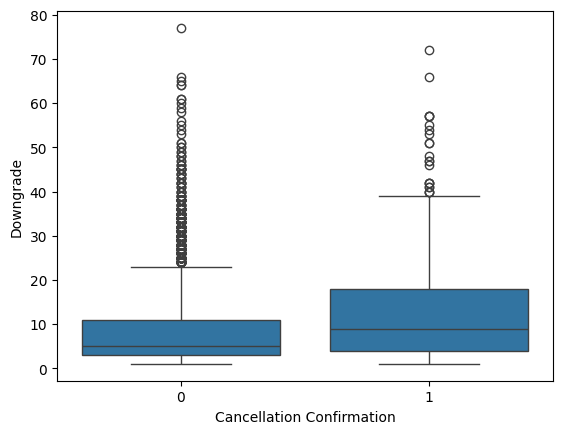

In [ ]:
#sns.boxplot(df_c, x = "Cancellation Confirmation", y = "Add Friend")

#sns.boxplot(df_c, x = "Cancellation Confirmation", y = "Add to Playlist")
#sns.boxplot(df_c, x = "Cancellation Confirmation", y = "Downgrade")

#sns.boxplot(df_c, x = "Cancellation Confirmation", y = "Error")
#sns.boxplot(df_c, x = "Cancellation Confirmation", y = "Help")

#sns.boxplot(df_c, x = "Cancellation Confirmation", y = "Save Settings")

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix
import numpy as np

In [91]:
df_c.columns

Index(['userId', 'About', 'Add Friend', 'Add to Playlist', 'Downgrade',
       'Error', 'Help', 'Home', 'Logout', 'NextSong', 'Roll Advert',
       'Save Settings', 'Settings', 'Submit Downgrade', 'Submit Upgrade',
       'Thumbs Down', 'Thumbs Up', 'Upgrade', 'Cancellation Confirmation'],
      dtype='object')

In [92]:
X = df_c[['About', 'Add Friend', 'Add to Playlist', 'Downgrade',
       'Error', 'Help', 'Home', 'Logout', 'NextSong', 'Roll Advert',
       'Save Settings', 'Settings', 'Submit Downgrade', 'Submit Upgrade',
       'Thumbs Down', 'Thumbs Up', 'Upgrade']]


y = df_c["Cancellation Confirmation"]

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
clf = HistGradientBoostingClassifier()#class_weight={np.int8(0): np.float64(0.5250034018233773),
 #np.int8(1): np.float64(10.498639455782312)})

In [108]:
clf.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [109]:
pred = clf.predict(X_test)

In [110]:
confusion_matrix(pred, y_test)

array([[3670,  183],
       [   4,    2]])